# ***Step 1: Load & Import Libraries***

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

# Graph Style
sns.set_style("whitegrid")

### ***1.1 Load Dataset***

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Student_Performance_Analysis /StudentsPerformance.csv")

df.head()

,Gender,Race / Ethnicity,Parental Level Of Education,Lunch,Test Preparation Course,Math Score,Reading Score,Writing Score
0,Female,Group B,Bachelor'S Degree,Standard,NaN,72,72,74
1,Female,Group C,Some College,Standard,Completed,69,90,88
2,Female,Group B,Master'S Degree,Standard,NaN,90,95,93
3,Male,Group A,Associate'S Degree,Free/Reduced,NaN,47,57,44
4,Male,Group C,Some College,Standard,NaN,76,78,75


### ***1.2 Basic Information***

In [ ]:
df.shape

(1000, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   Gender                        1000 non-null   object
 1   Race / Ethnicity              1000 non-null   object
 2   Parental Level Of Education   1000 non-null   object
 3   Lunch                         1000 non-null   object
 4   Test Preparation Course       358 non-null    object
 5   Math Score                    1000 non-null   int64 
 6   Reading Score                 1000 non-null   int64 
 7   Writing Score                 1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


### ***1.3 Check Missing Values***

In [ ]:
df.isnull().sum()

,0
Gender,0
Race / Ethnicity,0
Parental Level Of Education,0
Lunch,0
Test Preparation Course,642
Math Score,0
Reading Score,0
Writing Score,0


### ***1.4 Replace Missing Values***

In [ ]:
df["Test Preparation Course"] = df["Test Preparation Course"].fillna("None")

df.isnull().sum()

df["Test Preparation Course"] = (
    df["Test Preparation Course"]
    .fillna("None")
    .astype(str)
    .str.strip()
)

### ***1.5 Check Duplicate Records***

In [ ]:
df.duplicated().sum()

np.int64(0)

### ***1.6 Statistical Summary***

In [ ]:
df.describe()

,Math Score,Reading Score,Writing Score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


### ***1.7 Check Data Types***

In [ ]:
df.dtypes

,0
Gender,object
Race / Ethnicity,object
Parental Level Of Education,object
Lunch,object
Test Preparation Course,object
Math Score,int64
Reading Score,int64
Writing Score,int64


### ***1.8 Display Unique Values***

In [ ]:
for col in df.select_dtypes(include='object').columns:
    print("="*50)
    print(col)
    print(df[col].unique())

Gender
['Female' 'Male']
Race / Ethnicity
['Group B' 'Group C' 'Group A' 'Group D' 'Group E']
Parental Level Of Education 
["Bachelor'S Degree" 'Some College' "Master'S Degree" "Associate'S Degree"
 'High School' 'Some High School']
Lunch
['Standard' 'Free/Reduced']
Test Preparation Course
['None' 'Completed']


### ***1.9 Separate Numerical & Categorical Columns***

In [ ]:
cat_cols = df.select_dtypes(include='object').columns

num_cols = df.select_dtypes(exclude='object').columns

print("Categorical Columns")
print(cat_cols)

print()

print("Numerical Columns")
print(num_cols)

Categorical Columns
Index(['Gender', 'Race / Ethnicity', 'Parental Level Of Education ', 'Lunch',
       'Test Preparation Course'],
      dtype='object')

Numerical Columns
Index(['Math Score', 'Reading Score', 'Writing Score'], dtype='object')


# ***Step 2: Factor Analysis***

## ***Question 1 : Does parental education level affect scores?***

In [ ]:
df["Total Score"] = df["Math Score"] + df["Reading Score"] + df["Writing Score"]

parental_analysis = df.groupby("Parental Level Of Education ")[["Math Score", "Reading Score", "Writing Score", "Total Score"]].mean().round(2)

print(parental_analysis)

                              Math Score  Reading Score  Writing Score  \
Parental Level Of Education                                              
Associate'S Degree                 67.88          70.93          69.90   
Bachelor'S Degree                  69.39          73.00          73.38   
High School                        62.14          64.70          62.45   
Master'S Degree                    69.75          75.37          75.68   
Some College                       67.13          69.46          68.84   
Some High School                   63.50          66.94          64.89   

                              Total Score  
Parental Level Of Education                
Associate'S Degree                 208.71  
Bachelor'S Degree                  215.77  
High School                        189.29  
Master'S Degree                    220.80  
Some College                       205.43  
Some High School                   195.32  


Observation

* The analysis indicates that parental education level has a positive impact on student performance. Students whose parents have higher educational qualifications (especially Master's and Bachelor's degrees) achieved higher average scores, while students whose parents completed only high school had the lowest average scores.



## *Question 2 : Do students who complete the test preparation course score higher?*

In [ ]:
print(df["Test Preparation Course"].value_counts(dropna=False))
print()

testprep_analysis = df.groupby("Test Preparation Course")[
    ["Math Score", "Reading Score", "Writing Score", "Total Score"]
].mean().round(2)

print(testprep_analysis)

Test Preparation Course
None         642
Completed    358
Name: count, dtype: int64

                         Math Score  Reading Score  Writing Score  Total Score
Test Preparation Course                                                       
Completed                     69.70          73.89          74.42       218.01
None                          64.08          66.53          64.50       195.12


Observation

* Students who completed the test preparation course performed significantly better in all three subjects. Their average total score (218.01) is much higher than that of students who did not complete the course .

Conclusion

* Yes, students who completed the test preparation course scored higher than those who did not.


## ***Question 3: What is the correlation between reading, writing, and math scores?***

In [ ]:
correlation = df[["Math Score", "Reading Score", "Writing Score"]].corr()

print(correlation)

               Math Score  Reading Score  Writing Score
Math Score       1.000000       0.817580       0.802642
Reading Score    0.817580       1.000000       0.954598
Writing Score    0.802642       0.954598       1.000000


Observation

* All three subjects have a strong positive correlation. The highest correlation is between Reading Score and Writing Score (0.9546), indicating that students who perform well in reading also tend to perform well in writing. Math scores also show a strong positive relationship with both reading and writing scores.

Conclusion

* There is a strong positive correlation between math, reading, and writing scores, especially between reading and writing.


## ***Question 4: Which gender performs better in which subject?***

In [ ]:
gender_analysis = df.groupby("Gender")[
    ["Math Score", "Reading Score", "Writing Score"]
].mean().round(2)

print(gender_analysis)

        Math Score  Reading Score  Writing Score
Gender                                          
Female       63.63          72.61          72.47
Male         68.73          65.47          63.31


Observation

* Male students scored higher in Mathematics (68.73 vs. 63.63), while female students scored higher in Reading (72.61 vs. 65.47) and Writing (72.47 vs. 63.31). This indicates that performance varies by subject across genders.

Conclusion

* Male students perform better in Mathematics, whereas female students perform better in Reading and Writing.



## ***Question 5: What is the distribution of total scores?***

In [ ]:
df["Total Score"].describe()

print("\nDistribution of Total Scores:")
print(df["Total Score"].value_counts().sort_index())


Distribution of Total Scores:
Total Score
27     1
55     1
69     1
70     1
78     2
      ..
293    3
296    2
297    2
299    1
300    3
Name: count, Length: 194, dtype: int64


Observation

* The total scores range from 27 to 300, showing a wide variation in student performance. Most students scored in the middle range, while only a few students achieved extremely low or extremely high total scores. This indicates that the majority of students have average to good academic performance.

Conclusion

* The distribution of total scores suggests that most students perform at an average to good level, with only a small number of students falling into the very low or very high score categories.


# ***Step 3: Visualizations***

### **3.1 Box Plot (Scores by Parental Education)**

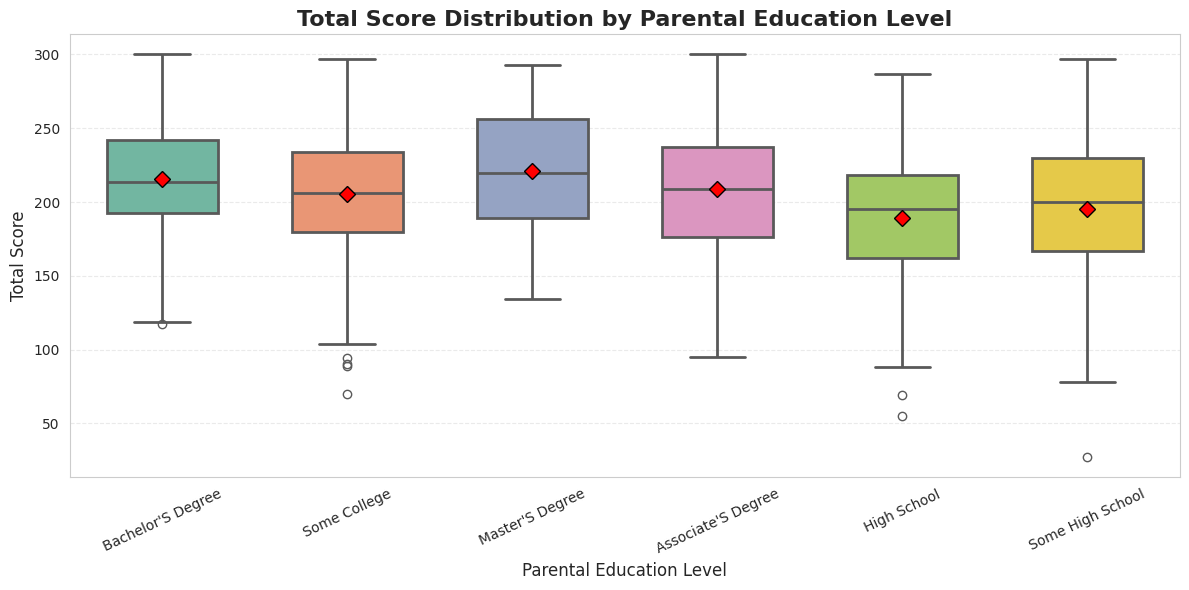

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="Parental Level Of Education ",
    y="Total Score",
    hue="Parental Level Of Education ",
    palette="Set2",
    legend=False,
    linewidth=2,
    width=0.6,
    showmeans=True,
    meanprops={
        "marker":"D",
        "markerfacecolor":"red",
        "markeredgecolor":"black",
        "markersize":8
    }
)

plt.title(
    "Total Score Distribution by Parental Education Level",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Parental Education Level", fontsize=12)
plt.ylabel("Total Score", fontsize=12)

plt.xticks(rotation=25)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

Observation

* Students whose parents have Master's and Bachelor's degrees generally achieve higher median total scores. Students whose parents have only a High School education tend to have lower scores and greater variation.

Conclusion

* Higher parental education is associated with better student academic performance.

Business Insight

* The school can provide additional mentoring, parent engagement programs, and academic support for students whose parents have lower education levels to help reduce the achievement gap.

### ***3.2 Bar Chart (Test Preparation Course Comparison)***

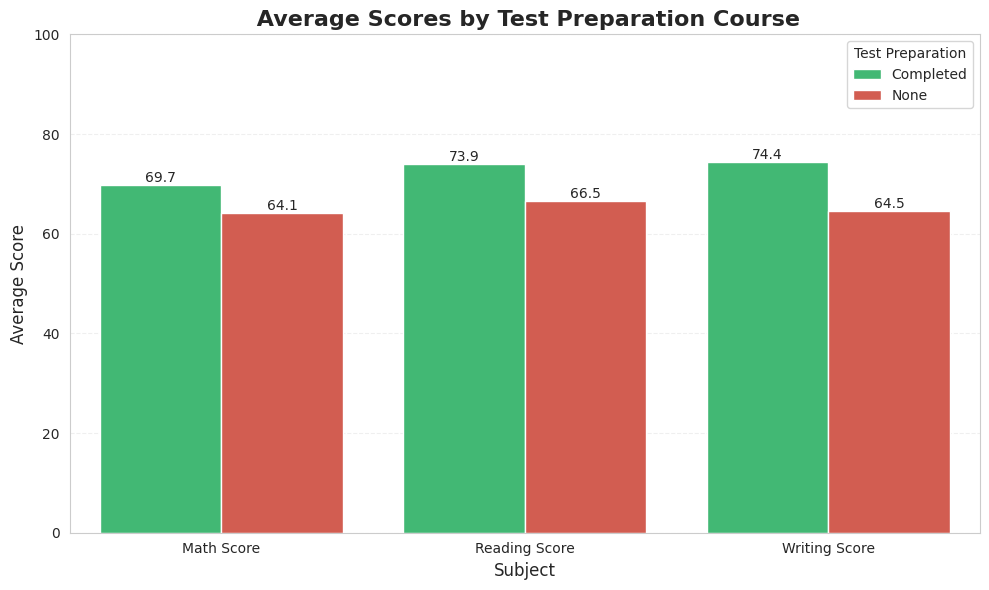

In [ ]:
testprep_scores = (
    df.groupby("Test Preparation Course")[["Math Score","Reading Score","Writing Score"]]
    .mean()
    .reset_index()
)

testprep_melt = testprep_scores.melt(
    id_vars="Test Preparation Course",
    var_name="Subject",
    value_name="Average Score"
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=testprep_melt,
    x="Subject",
    y="Average Score",
    hue="Test Preparation Course",
    hue_order=["Completed", "None"],
    palette=["#2ECC71", "#E74C3C"]
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", fontsize=10)

plt.title(" Average Scores by Test Preparation Course", fontsize=16, weight="bold")
plt.xlabel("Subject", fontsize=12)
plt.ylabel("Average Score", fontsize=12)
plt.ylim(0,100)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.legend(title="Test Preparation")
plt.tight_layout()

plt.show()

Observation

* Students who completed the test preparation course scored higher in Math, Reading, and Writing than students who did not complete the course.

Conclusion

* Completing the test preparation course has a positive association with student performance across all subjects.

Business Insight

* The school should encourage more students to participate in test preparation programs by offering awareness sessions, incentives, or free support classes, as these programs appear to improve academic outcomes.

### ***3.3 Correlation Heatmap (Reading, Writing & Math)***

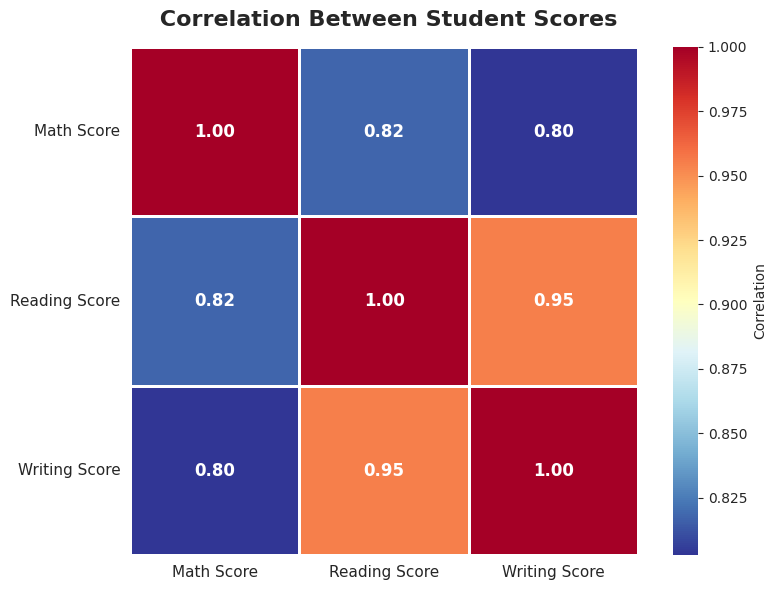

In [ ]:
# Correlation matrix
corr = df[["Math Score", "Reading Score", "Writing Score"]].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="RdYlBu_r",
    linewidths=1,
    linecolor="white",
    square=True,
    fmt=".2f",
    annot_kws={"size":12,"weight":"bold"},
    cbar_kws={"label":"Correlation"}
)

plt.title(" Correlation Between Student Scores",
          fontsize=16,
          weight="bold",
          pad=15)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0)

plt.tight_layout()
plt.show()

Observation

* Reading and Writing scores have the strongest positive correlation, while Math also shows a strong positive relationship with both Reading and Writing.

Conclusion

* Students who perform well in one subject generally perform well in the others, especially in Reading and Writing.

Business Insight

* The school can design integrated learning activities that strengthen reading and writing skills together, while also using cross-subject teaching strategies to improve overall academic performance.

### ***3.4 Grouped Bar Chart (Gender vs Subject)***

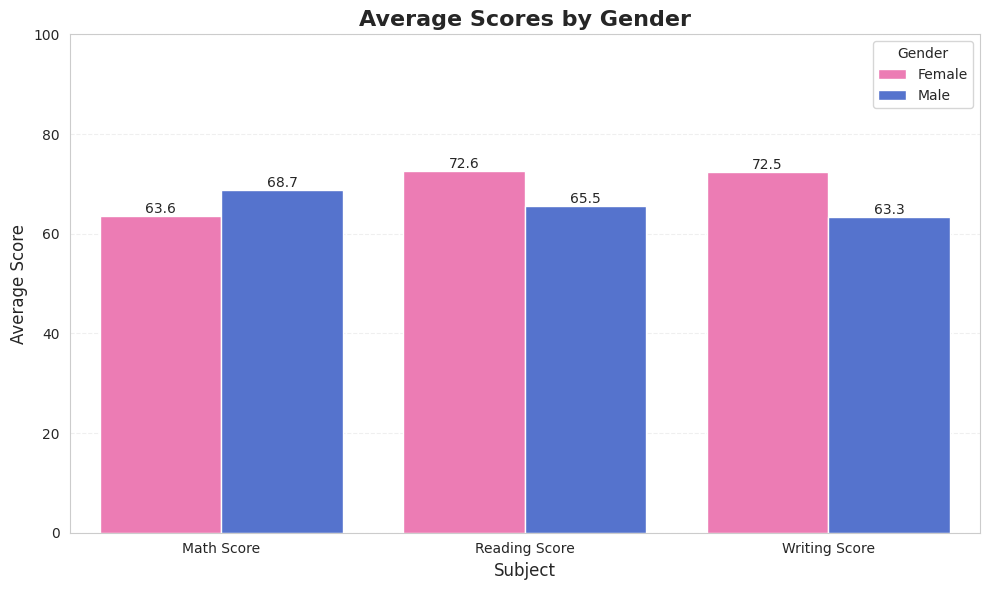

In [ ]:
# Average scores by gender
gender_scores = (
    df.groupby("Gender")[["Math Score", "Reading Score", "Writing Score"]]
    .mean()
    .reset_index()
)

# Convert to long format
gender_melt = gender_scores.melt(
    id_vars="Gender",
    var_name="Subject",
    value_name="Average Score"
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=gender_melt,
    x="Subject",
    y="Average Score",
    hue="Gender",
    palette={"Female":"#FF69B4", "Male":"#4169E1"}
)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", fontsize=10)

plt.title("Average Scores by Gender", fontsize=16, weight="bold")
plt.xlabel("Subject", fontsize=12)
plt.ylabel("Average Score", fontsize=12)
plt.ylim(0,100)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.legend(title="Gender")
plt.tight_layout()

plt.show()

Observation

* Male students have a higher average score in Mathematics, whereas female students perform better in Reading and Writing.

Conclusion

* Academic performance differs by subject across genders.

Business Insight

* The school can implement subject-specific learning strategies, such as additional Mathematics workshops for female students and reading/writing support programs for male students, to reduce performance gaps.

### ***3.5 Histogram – Total Score Distribution***

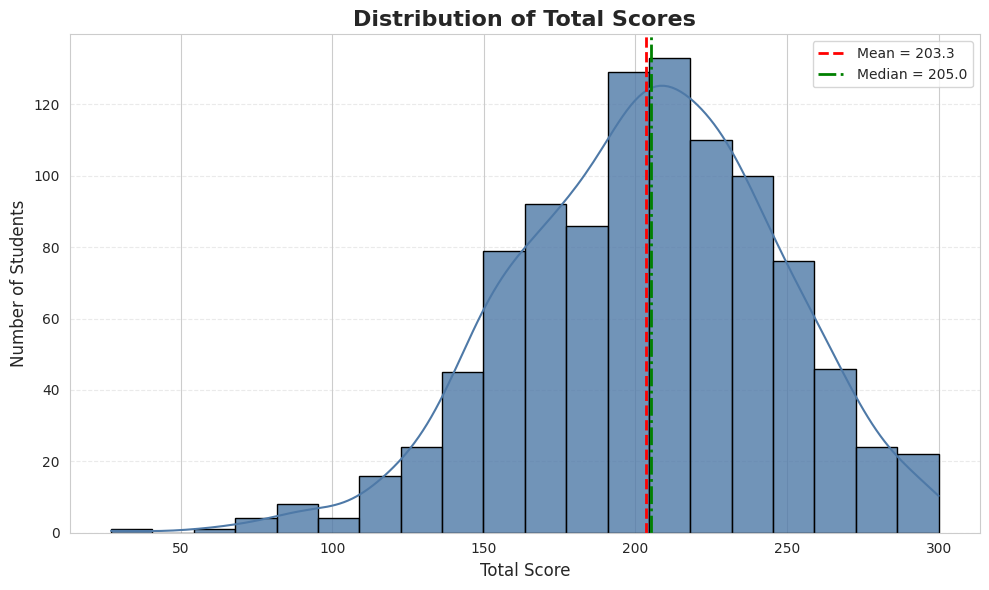

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="Total Score",
    bins=20,
    kde=True,
    color="#4E79A7",
    edgecolor="black",
    alpha=0.8
)

# Mean line
plt.axvline(
    df["Total Score"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {df['Total Score'].mean():.1f}"
)

# Median line
plt.axvline(
    df["Total Score"].median(),
    color="green",
    linestyle="-.",
    linewidth=2,
    label=f"Median = {df['Total Score'].median():.1f}"
)

plt.title("Distribution of Total Scores", fontsize=16, weight="bold")
plt.xlabel("Total Score", fontsize=12)
plt.ylabel("Number of Students", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.legend()

plt.tight_layout()
plt.show()

Observation

* Most students' total scores are concentrated in the middle range, with relatively few students scoring at the very low or very high ends.

Conclusion

* The majority of students demonstrate average to good academic performance, while only a small proportion are low or exceptionally high achievers.

Business Insight

* The school should focus on improving the performance of lower-scoring students through remedial support while providing enrichment opportunities for high-performing students to maintain excellence.

### ***3.6 Scatter Plot – Reading Score vs Math Score***

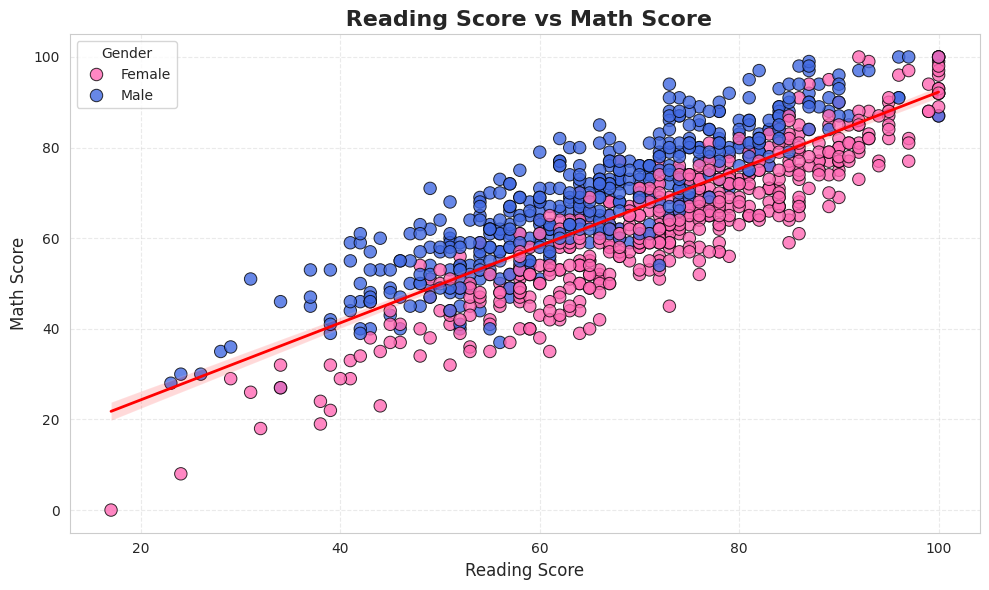

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Reading Score",
    y="Math Score",
    hue="Gender",
    palette={"Female":"#FF69B4", "Male":"#4169E1"},
    s=80,
    alpha=0.8,
    edgecolor="black"
)

# Regression line
sns.regplot(
    data=df,
    x="Reading Score",
    y="Math Score",
    scatter=False,
    color="red",
    line_kws={"linewidth":2}
)

plt.title(" Reading Score vs Math Score", fontsize=16, weight="bold")
plt.xlabel("Reading Score", fontsize=12)
plt.ylabel("Math Score", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.4)

plt.legend(title="Gender")

plt.tight_layout()
plt.show()

Observation

* The scatter plot shows a clear positive relationship between Reading and Math scores. Students with higher Reading scores generally achieve higher Math scores.

Conclusion

* Reading and Mathematics performance are positively correlated, indicating that improvement in one area is often associated with improvement in the other.

Business Insight

* The school can adopt integrated teaching approaches that strengthen reading comprehension alongside mathematical problem-solving. Early identification of students who deviate from the general trend can help teachers provide targeted academic interventions.

# ***Step 4: At-Risk Student Segmentation***

### ***4.1: Create an At-Risk Column***

In [ ]:
df["At Risk"] = (
    (df["Math Score"] < 40) |
    (df["Reading Score"] < 40) |
    (df["Writing Score"] < 40)
)

df["At Risk"] = df["At Risk"].map({True: "Yes", False: "No"})

### ***4.2: Count At-Risk Students***

In [ ]:
df["At Risk"].value_counts()

,count
At Risk,
No,949
Yes,51


### ***4.3: Percentage of At-Risk Students***

In [ ]:
risk_percentage = (
    df["At Risk"]
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)

print(risk_percentage)

At Risk
No     94.9
Yes     5.1
Name: proportion, dtype: float64


## ***4.4: At-Risk Segmentation by Gender***

In [ ]:
risk_gender = pd.crosstab(
    df["Gender"],
    df["At Risk"],
    margins=True
)

print(risk_gender)

At Risk   No  Yes   All
Gender                 
Female   487   31   518
Male     462   20   482
All      949   51  1000


## ***4.5: At-Risk Segmentation by Test Preparation Course***

In [ ]:
risk_testprep = pd.crosstab(
    df["Test Preparation Course"],
    df["At Risk"],
    margins=True
)

print(risk_testprep)

At Risk                   No  Yes   All
Test Preparation Course                
Completed                351    7   358
None                     598   44   642
All                      949   51  1000


## ***4.6: At-Risk Segmentation by Parental Education***

In [ ]:
risk_parent = pd.crosstab(
    df["Parental Level Of Education "],
    df["At Risk"],
    margins=True
)

print(risk_parent)

At Risk                        No  Yes   All
Parental Level Of Education                 
Associate'S Degree            217    5   222
Bachelor'S Degree             114    4   118
High School                   180   16   196
Master'S Degree                59    0    59
Some College                  216   10   226
Some High School              163   16   179
All                           949   51  1000


Observation

* Students identified as At Risk scored below the threshold in at least one subject. The segmentation tables show how these students are distributed across gender, test preparation status, and parental education levels, helping identify groups that may benefit from additional academic support.

Conclusion

* At-risk segmentation enables the school to identify students who require early intervention and targeted learning assistance before their performance declines further.

Business Insight

* The school can prioritize remedial classes, mentoring, and counseling for at-risk students, especially in groups where the proportion of at-risk students is higher. This supports better academic outcomes and more effective allocation of educational resources.

# ***Step 5: Principal's Report***

Student Performance Analysis Report

## Objective

* The objective of this analysis was to examine student performance using factors such as parental education level, gender, lunch type, and test preparation course. The goal was to identify key factors affecting academic achievement and provide recommendations to improve student outcomes.

## Key Findings

1.   Parental Education
     * Students whose parents have higher education levels (Master's or Bachelor's degrees) generally achieved higher average scores.
2.  Test Preparation Course
      * Students who completed the test preparation course performed significantly better in Mathematics, Reading, and Writing.
3.  Subject Correlation
      * Reading and Writing scores showed the strongest positive correlation, indicating that students who perform well in one language subject often perform well in the other.
4.  Gender Performance
      * Male students performed better in Mathematics.
Female students achieved higher average scores in Reading and Writing.
5.  Overall Performance
      * Most students achieved average to good total scores, while a smaller group of students requires additional academic support.
6.  At-Risk Students
      * Students scoring below the defined threshold were identified as at-risk and should receive targeted academic assistance.


## Recommendations

* Increase participation in test preparation courses.
* Provide remedial classes for at-risk students.
* Strengthen reading and writing programs while maintaining mathematics support.
* Encourage parental involvement in students' academic activities.
* Monitor student performance regularly using data-driven dashboards.

## Expected Outcomes

By implementing these recommendations, the school can:

* Improve overall academic performance.
* Reduce the number of at-risk students.
* Increase student engagement.
* Support informed decision-making using data analysis.

# ***Step 6: Executive Summary***

## Executive Summary

* This project analyzed the academic performance of students using Python-based data analysis and visualization techniques. Data cleaning and exploratory analysis were performed to understand the dataset and identify important trends.

* The analysis showed that parental education level and completion of the test preparation course positively influence student performance. Reading and Writing scores were highly correlated, while gender-based analysis revealed that male students performed better in Mathematics and female students excelled in Reading and Writing.

* An at-risk student segmentation was also conducted to identify students requiring academic intervention. Based on the findings, several recommendations were proposed to improve student performance and support educational planning.

* Overall, the project demonstrates how data analytics can help schools make informed decisions and improve student outcomes.